# Retail Performance Analytics

# Business Analysis

This notebook builds on the work completed in the previous stages of the project.

After understanding the dataset and preparing it for analysis, the focus shifts to answering business questions using the cleaned data.

Each section explores one business question, presents the results and explains what they mean for the business.

## Project Roadmap

| Stage | Status |
|--------|--------|
| Business Understanding | ✅ Completed |
| Data Understanding | ✅ Completed |
| Data Cleaning | ✅ Completed |
| Business Analysis | 🟡 In Progress |
| SQL Analysis | ⏳ Planned |
| Power BI Dashboard | ⏳ Planned |
| Executive Report | ⏳ Planned |

## Notebook Objectives

This notebook aims to:

- Assess overall business performance.
- Identify the most valuable customers.
- Evaluate product performance.
- Compare sales across countries.
- Analyse sales trends over time.

## Analytical Approach

Each section answers a business question using the cleaned dataset.

The results are then interpreted through observations and business insights.

## Business Questions

This analysis seeks to answer the following business questions:

1. How is the business performing overall?
2. Who are the most valuable customers?
3. Which products drive revenue?
4. How does sales performance vary across countries?
5. How do sales evolve over time?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Pandas display options
pd.set_option("display.max_columns", None)

# Matplotlib default style
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#### Load Clean Dataset

In [14]:
clean_df = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={
        "InvoiceNo": str,
        "StockCode": str
    },
    parse_dates=["InvoiceDate"]
)

#### Observation

The cleaned dataset generated in the previous notebook is loaded from the **processed** folder.

InvoiceNo and StockCode are imported as text because they are business identifiers, while InvoiceDate is imported as a datetime column.

#### Dataset Overview

In [13]:
rows, columns = clean_df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 525,460
Columns: 8


#### Observation

The cleaned dataset contains only valid retail sales transactions after applying the cleaning rules defined in the previous notebook.

It is now ready for the business analyses presented throughout this project.

## Feature Engineering

The following variables are created to support the analyses presented in this notebook.

#### Line Total

The original dataset stores the quantity sold and the unit price separately.

The new variable combines both values and represents the total amount for each transaction line.

In [23]:
clean_df["LineTotal"] = (
    clean_df["Quantity"] *
    clean_df["UnitPrice"]
)

#### Validation

In [24]:
clean_df["LineTotal"].describe()

count    525460.000000
mean         20.252942
std         271.543898
min           0.000000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: LineTotal, dtype: float64

#### Observation

LineTotal represents the value of each transaction line and will be used in the analyses throughout this notebook.

### Year

The **Year** variable separates transactions by calendar year.

Although this dataset covers only two years, this variable makes it easier to organise the results by year.

In [17]:
clean_df["Year"] = (
    clean_df["InvoiceDate"]
    .dt.year
)

### Month

The **Month** variable stores the month as a number, making it easier to keep charts and tables in chronological order.

In [18]:
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.month
)

### Month Name

The **MonthName** variable displays the month names, making tables and charts easier to read.

In [19]:
clean_df["MonthName"] = (
    clean_df["InvoiceDate"]
    .dt.month_name()
)

### Day of Week

The **DayOfWeek** variable is used to compare sales across the days of the week.

In [20]:
clean_df["DayOfWeek"] = (
    clean_df["InvoiceDate"]
    .dt.day_name()
)

### Hour

The **Hour** variable helps identify the busiest shopping hours.

In [21]:
clean_df["Hour"] = (
    clean_df["InvoiceDate"]
    .dt.hour
)

#### Validation

In [25]:
clean_df[
    [
        "InvoiceDate",
        "LineTotal",
        "Year",
        "Month",
        "MonthName",
        "DayOfWeek",
        "Hour"
    ]
].head()

,InvoiceDate,LineTotal,Year,Month,MonthName,DayOfWeek,Hour
0,2010-12-01 08:26:00,15.30,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,22.00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8


#### Observation

The new variables are now available for the remaining analyses in this notebook.

# Business Question 1

## How is the business performing overall?

This section provides an overview of the business before exploring customers, products, countries and sales trends in more detail.

### Business KPIs

#### Total Sales

In [27]:
total_sales = clean_df["LineTotal"].sum()

print(f"Total Sales: £{total_sales:,.2f}")

Total Sales: £10,642,110.80


#### Observation

Total Sales represents the total value of all completed sales included in the analytical dataset.

---

#### Total Orders

In [26]:
total_orders = clean_df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 20,134


#### Observation

Each invoice represents one completed order.

Counting unique invoice numbers provides the total number of orders analysed.

---

#### Average Order Value

Average Order Value is calculated by dividing total sales by the number of completed orders.

In [36]:
invoice_total = (
    clean_df
    .groupby("InvoiceNo")["LineTotal"]
    .sum()
)

average_order_value = invoice_total.mean()

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £528.56


#### Observation

On average, customers spent **£528.56** per completed order.

#### Total Customers

In [28]:
total_customers = clean_df["CustomerID"].nunique()

print(f"Identified Customers: {total_customers:,}")

Identified Customers: 4,339


#### Observation

This metric includes only customers with a valid customer identifier.

Anonymous purchases remain part of the sales analysis but are not included in customer-level metrics.

---

#### Unique Products

In [37]:
unique_Products = clean_df["StockCode"].nunique()

print(f"unique Products: {unique_Products:,}")

unique Products: 3,925


#### Observation

This metric shows how many different products were sold during the analysed period.

---

#### Countries

In [30]:
total_countries = clean_df["Country"].nunique()

print(f"Countries: {total_countries}")

Countries: 38


#### Observation

Sales were recorded across multiple countries.

Country-level performance will be explored later in the notebook.

### Business Insight

These KPIs provide an overall picture of the business.

The following sections examine customers, products, countries and sales trends to understand the results in more detail.

---

# Business Question 2

## Who are the most valuable customers?

This section identifies the customers who contribute most to total sales.

The analysis focuses on customer spending and purchase frequency to understand how revenue is distributed across the customer base.

### Customer Revenue

In [56]:
customer_summary = (
    clean_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        TotalSales=("LineTotal", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsPurchased=("Quantity", "sum")
    )
    .sort_values(
        by="TotalSales",
        ascending=False
    )
)

customer_summary.head(10)

,TotalSales,Orders,ItemsPurchased
CustomerID,,,
14646.0,280206.02,74,197491
18102.0,259657.30,60,64124
17450.0,194390.79,46,69973
16446.0,168472.50,2,80997
14911.0,143711.17,201,80490
12415.0,124914.53,21,77670
14156.0,117210.08,55,57768
17511.0,91062.38,31,64549
16029.0,80850.84,63,40108


#### Observation

A small number of customers generated substantially more sales than the rest of the customer base.

The table also shows that high customer value is not determined only by the number of orders, but also by the amount spent in each purchase.

In [60]:
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalSales"] /
    customer_summary["Orders"]
).round(2)

customer_summary.head(10)

,TotalSales,Orders,ItemsPurchased,AverageOrderValue
CustomerID,,,,
14646.0,280206.02,74,197491,3786.57
18102.0,259657.30,60,64124,4327.62
17450.0,194390.79,46,69973,4225.89
16446.0,168472.50,2,80997,84236.25
14911.0,143711.17,201,80490,714.98
12415.0,124914.53,21,77670,5948.31
14156.0,117210.08,55,57768,2131.09
17511.0,91062.38,31,64549,2937.50
16029.0,80850.84,63,40108,1283.35


#### Observation

Customer value is influenced by more than the number of orders.

Some customers generate high revenue through a relatively small number of purchases, suggesting larger average order values or higher purchase volumes.

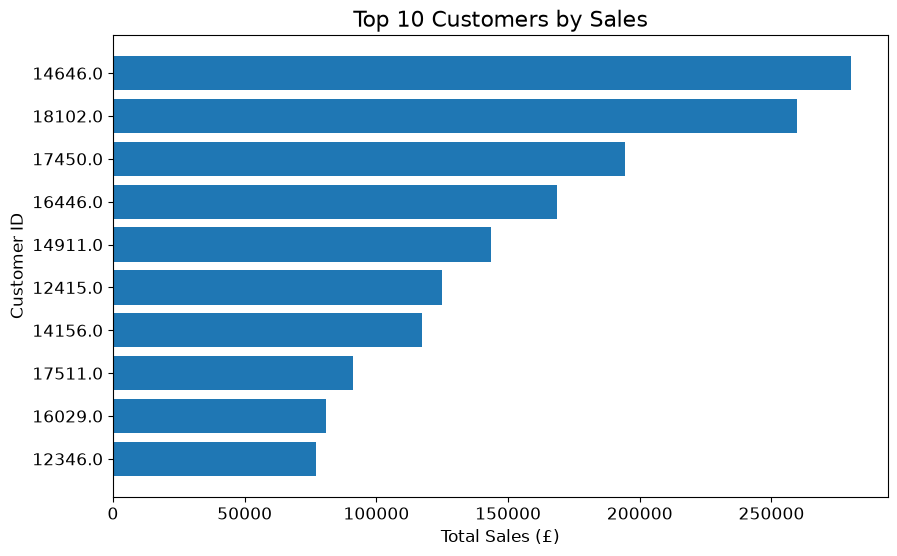

In [61]:
top_customers = (
    customer_revenue
    .head(10)
    .sort_values("TotalSales")
)

plt.figure(figsize=(10,6))

plt.barh(
    top_customers.index.astype(str),
    top_customers["TotalSales"]
)

plt.title("Top 10 Customers by Sales")

plt.xlabel("Total Sales (£)")

plt.ylabel("Customer ID")

plt.show()

#### Purchase Frequency

In [58]:
top_orders = (
    customer_summary
    .sort_values(
        by="Orders",
        ascending=False
    )
    .head(10)
)

top_orders

,TotalSales,Orders,ItemsPurchased
CustomerID,,,
12748.0,33053.19,210,25288
14911.0,143711.17,201,80490
17841.0,40519.84,124,22834
13089.0,58762.08,97,31025
14606.0,12076.15,93,6187
15311.0,60632.75,91,38147
12971.0,11189.91,86,9289
14646.0,280206.02,74,197491
16029.0,80850.84,63,40108


#### Observation

The top 10 customers generated substantially higher sales than the rest of the customer base.

This indicates that a relatively small group of customers contributes a significant share of the company's revenue.

### Business Insight

Looking at sales together with purchase frequency provides a more complete view of customer behaviour.

Customers who generate the highest revenue are not always those who place the greatest number of orders, highlighting different purchasing patterns across the customer base.